In [1]:
import os

if not os.path.exists("/content/palmistry"):
    !git clone https://github.com/yeonsumia/palmistry.git

%cd /content/palmistry

!pip uninstall -y tensorflow tensorflow-metadata ydf grain jax jaxlib --quiet
!pip install torch torchvision scikit-image opencv-python pillow-heif --quiet
!pip install "mediapipe==0.10.13" --quiet

print("Setup done — now go to Runtime > Restart session, then run Cell 2.")

Cloning into 'palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 17.11 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.
/content/palmistry
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 49.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [2]:
import os
os.chdir("/content/palmistry")

import mediapipe
print("mediapipe:", mediapipe.__version__)

path = "code/classification.py"
content = open(path).read()
old = "skel_img = cv2.cvtColor(skeletonize(palmline_img), cv2.COLOR_BGR2GRAY)"
new = "skel_img = cv2.cvtColor((skeletonize(palmline_img) * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)"
if old in content:
    open(path, "w").write(content.replace(old, new))
    print("Patched")
elif new in content:
    print("Already patched")
else:
    print("Line not found — check manually")

mediapipe: 0.10.13
Patched


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

info = pd.read_csv("/content/drive/MyDrive/palm_dataset/HandInfo.csv")
print(info.columns.tolist())

palmar_info = info[info["aspectOfHand"].str.contains("palmar", case=False, na=False)]
print(len(palmar_info), "palmar images out of", len(info))

['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish', 'aspectOfHand', 'imageName', 'irregularities']
5396 palmar images out of 11076


In [5]:
import os, shutil

src_dir = "/content/drive/MyDrive/palm_dataset/Hands/Hands"
dst_dir = "/content/drive/MyDrive/palm_dataset/palmar_only"
os.makedirs(dst_dir, exist_ok=True)

copied = 0
for fname in palmar_info["imageName"]:
    src = os.path.join(src_dir, fname)
    dst = os.path.join(dst_dir, fname)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        copied += 1

print("Newly copied:", copied, "| Total in palmar_only:", len(os.listdir(dst_dir)))

Newly copied: 0 | Total in palmar_only: 5396


In [6]:
import os, random

palmar_dir = "/content/drive/MyDrive/palm_dataset/palmar_only"
all_palmar = os.listdir(palmar_dir)

random.seed(42)
sample_files = random.sample(all_palmar, 25)
print(sample_files)

['Hand_0000911.jpg', 'Hand_0000061.jpg', 'Hand_0010329.jpg', 'Hand_0006066.jpg', 'Hand_0005531.jpg', 'Hand_0009487.jpg', 'Hand_0007999.jpg', 'Hand_0011630.jpg', 'Hand_0002346.jpg', 'Hand_0011386.jpg', 'Hand_0003137.jpg', 'Hand_0004469.jpg', 'Hand_0010450.jpg', 'Hand_0010424.jpg', 'Hand_0011492.jpg', 'Hand_0009400.jpg', 'Hand_0009662.jpg', 'Hand_0001630.jpg', 'Hand_0003354.jpg', 'Hand_0010376.jpg', 'Hand_0002703.jpg', 'Hand_0009041.jpg', 'Hand_0001108.jpg', 'Hand_0002343.jpg', 'Hand_0004411.jpg']


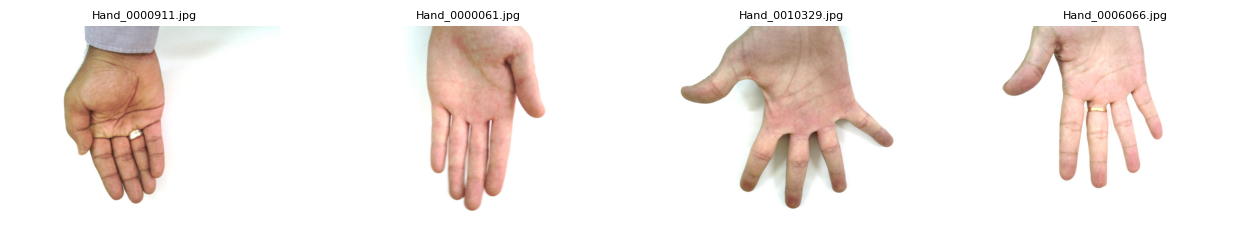

In [7]:
import matplotlib.pyplot as plt
import cv2
import os

palmar_dir = "/content/drive/MyDrive/palm_dataset/palmar_only"
check_files = sample_files[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, fname in zip(axes, check_files):
    img = cv2.imread(os.path.join(palmar_dir, fname))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, fontsize=8)
    ax.axis("off")
plt.show()

In [8]:
import subprocess, os, shutil

def run_palm_analysis(image_path, repo_code_dir="/content/palmistry/code"):
    filename = os.path.basename(image_path)
    dest = os.path.join(repo_code_dir, "input", filename)
    shutil.copy(image_path, dest)

    result = subprocess.run(
        ["python", "read_palm.py", "--input", filename],
        cwd=repo_code_dir, capture_output=True, text=True, timeout=180
    )

    result_path = os.path.join(repo_code_dir, "results", "result.jpg")
    success = result.returncode == 0 and os.path.exists(result_path)

    saved_result_path = None
    if success:
        saved_result_path = os.path.join(repo_code_dir, "results", f"result_{filename}")
        shutil.copy(result_path, saved_result_path)

    return {
        "filename": filename,
        "success": success,
        "result_image_path": saved_result_path,
        "stdout": result.stdout[-500:],
        "stderr": result.stderr[-500:] if not success else None
    }

In [9]:
palmar_dir = "/content/drive/MyDrive/palm_dataset/palmar_only"

batch_results = []
for fname in sample_files:
    src_path = os.path.join(palmar_dir, fname)
    r = run_palm_analysis(src_path)
    batch_results.append(r)
    print(fname, "->", r["success"])

Hand_0000911.jpg -> True
Hand_0000061.jpg -> True
Hand_0010329.jpg -> True
Hand_0006066.jpg -> True
Hand_0005531.jpg -> True
Hand_0009487.jpg -> True
Hand_0007999.jpg -> True
Hand_0011630.jpg -> True
Hand_0002346.jpg -> True
Hand_0011386.jpg -> True
Hand_0003137.jpg -> True
Hand_0004469.jpg -> True
Hand_0010450.jpg -> True
Hand_0010424.jpg -> True
Hand_0011492.jpg -> True
Hand_0009400.jpg -> True
Hand_0009662.jpg -> True
Hand_0001630.jpg -> True
Hand_0003354.jpg -> True
Hand_0010376.jpg -> True
Hand_0002703.jpg -> True
Hand_0009041.jpg -> True
Hand_0001108.jpg -> True
Hand_0002343.jpg -> True
Hand_0004411.jpg -> True


In [10]:
successes = sum(r["success"] for r in batch_results)
print(f"{successes}/{len(batch_results)} succeeded")

failed = [r["filename"] for r in batch_results if not r["success"]]
print("Failed files:", failed)

25/25 succeeded
Failed files: []


Displaying 25 results


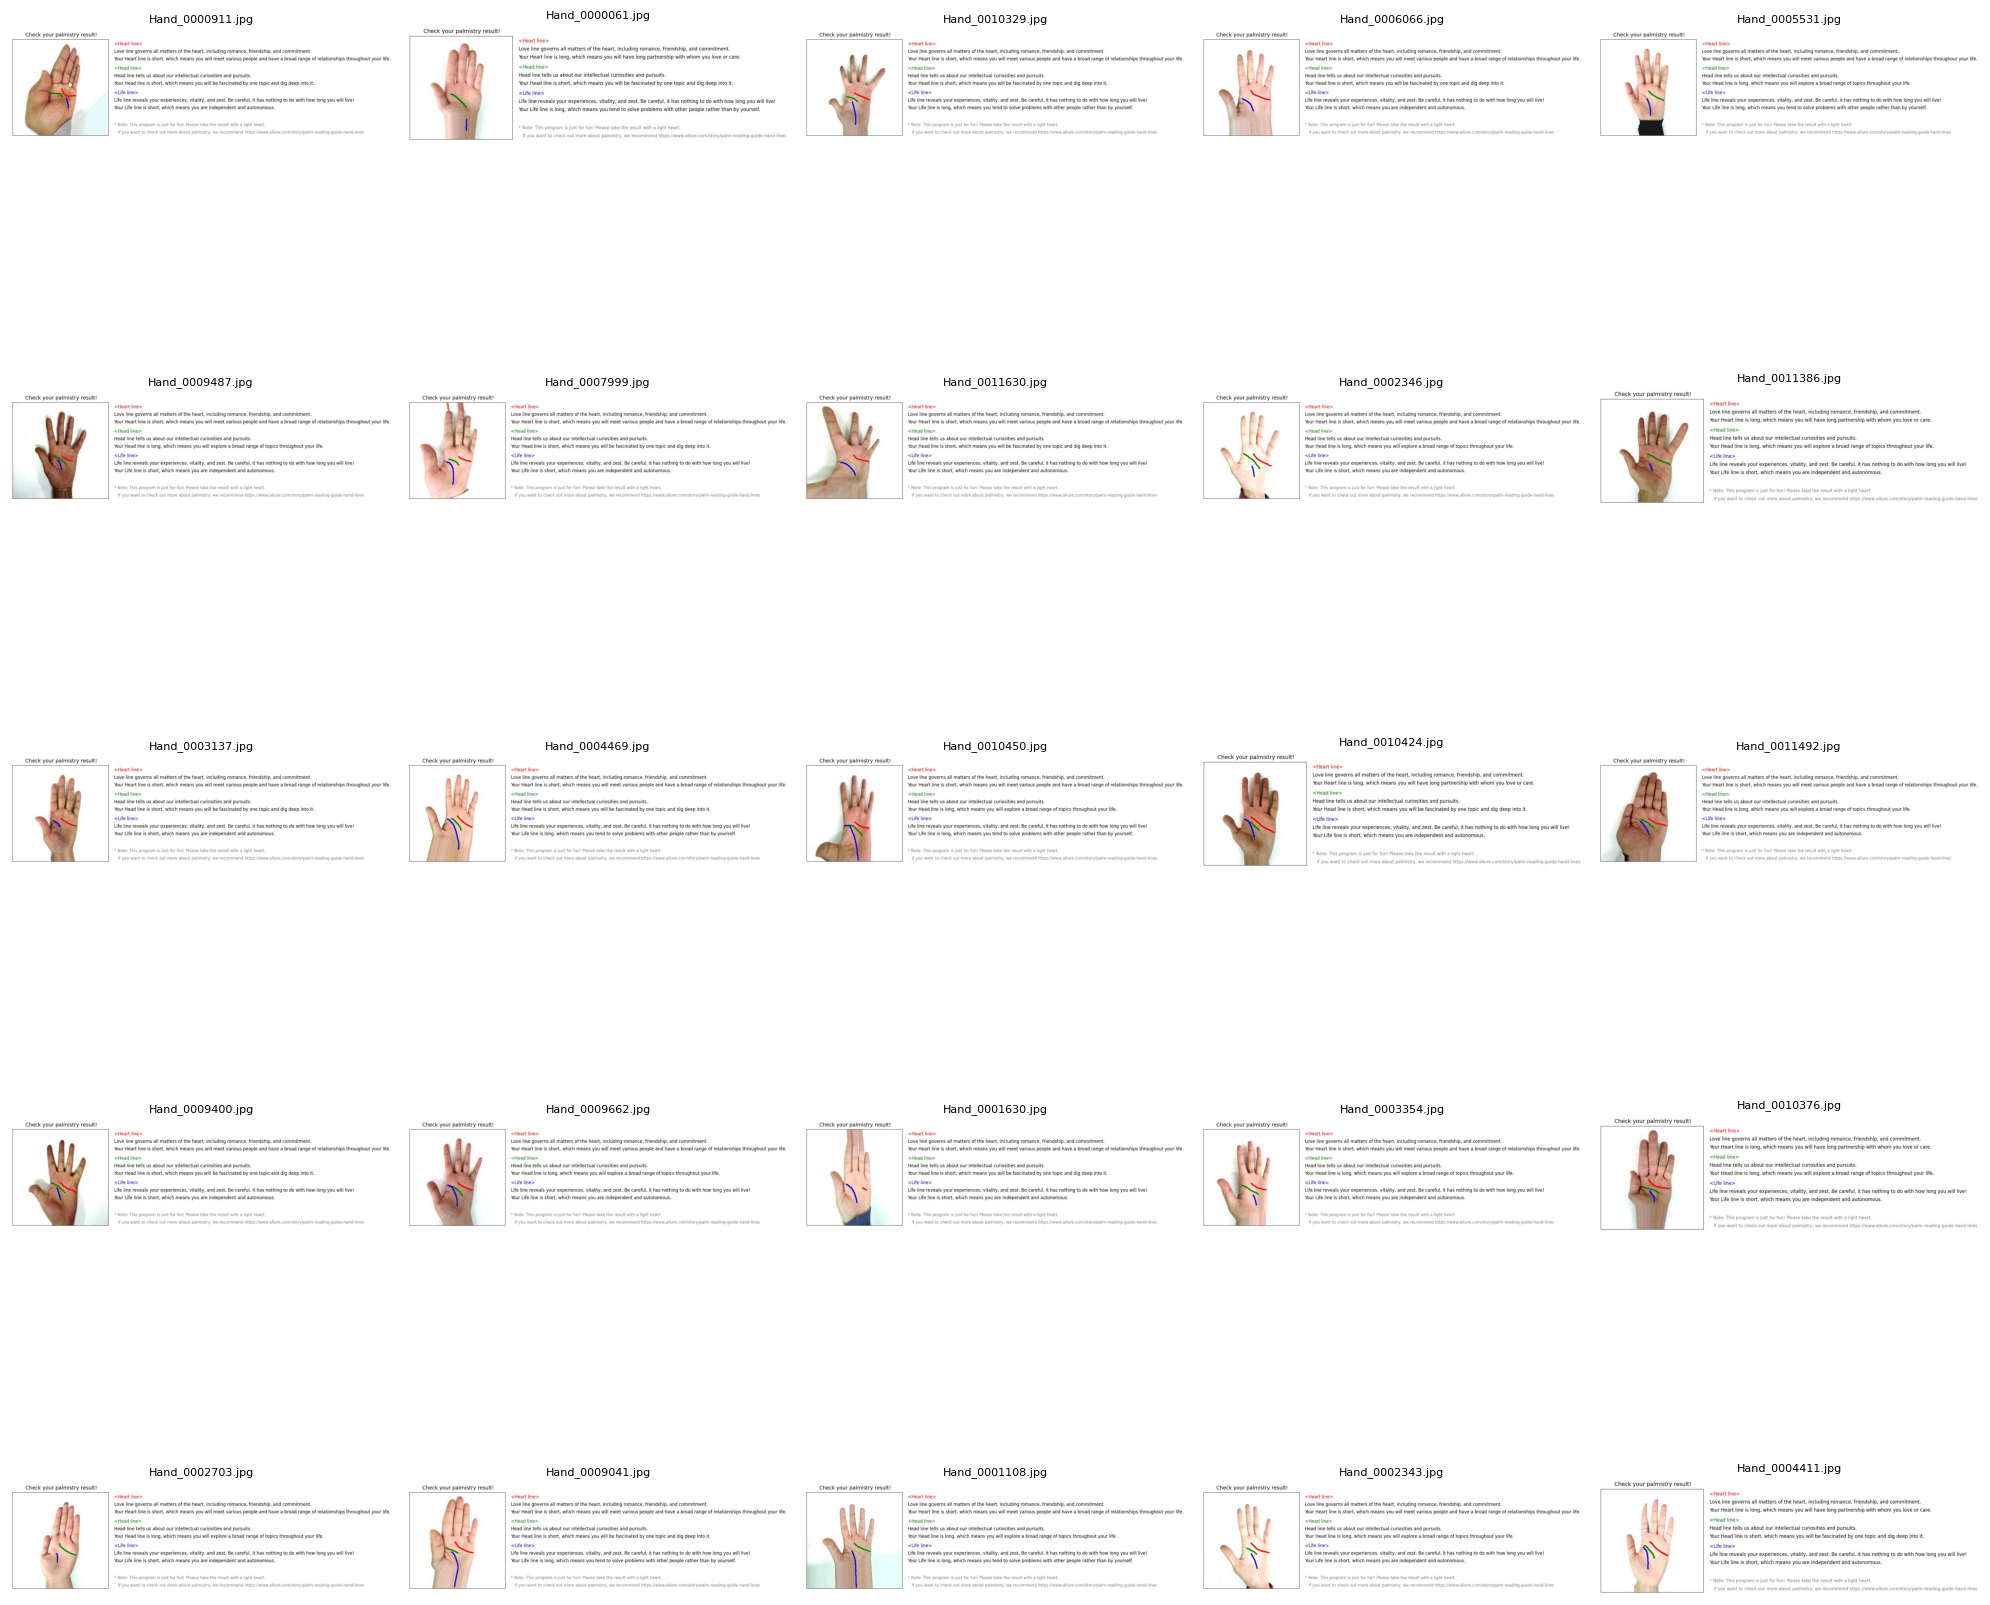

In [11]:
import matplotlib.pyplot as plt
import cv2

successful_results = [r for r in batch_results if r["success"]]
print(f"Displaying {len(successful_results)} results")

n = len(successful_results)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for ax, r in zip(axes, successful_results):
    img = cv2.imread(r["result_image_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(r["filename"], fontsize=8)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

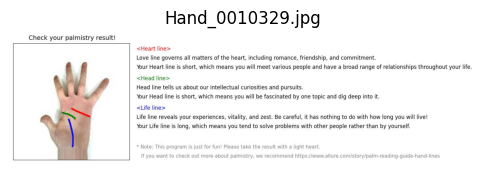

In [12]:
idx = 2
r = successful_results[idx]
img = cv2.imread(r["result_image_path"])
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(r["filename"])
plt.axis("off")
plt.show()

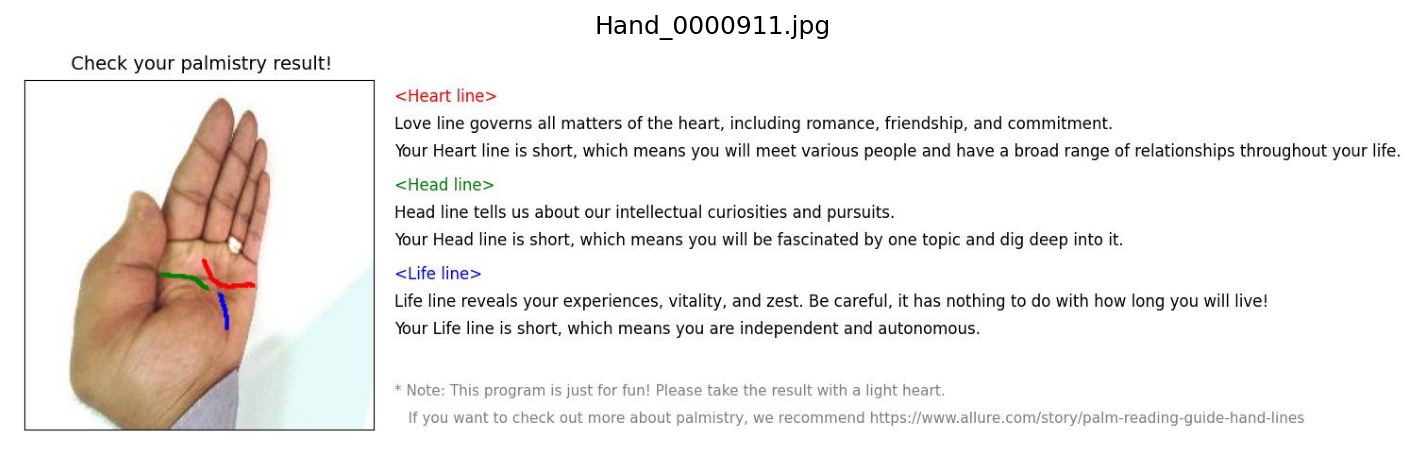

Scored Hand_0000911.jpg: 2/3


In [13]:
idx = 0
r = successful_results[idx]
img = cv2.imread(r["result_image_path"])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8), dpi=150)
plt.imshow(img_rgb)
plt.axis("off")
plt.title(r["filename"])
plt.show()

correct = 2  # <-- just set the number manually here instead of typing it
print(f"Scored {r['filename']}: {correct}/3")

In [14]:
# ===== Palm Engine — Summary =====

successes = sum(r["success"] for r in batch_results)
print(f"Batch run on own dataset: {successes}/{len(batch_results)} images processed successfully")

# Reference accuracy from the model's own validation (PLSU dataset, ground-truth masks)
# Source: palmistry-main repo's detect/palmistry_detector.ipynb evaluation
plsu_f1_scores  = [0.696, 0.724, 0.625, 0.561, 0.686, 0.717, 0.644, 0.716, 0.682, 0.652]
plsu_iou_scores = [0.534, 0.567, 0.454, 0.389, 0.522, 0.559, 0.475, 0.557, 0.517, 0.484]

avg_f1  = sum(plsu_f1_scores)  / len(plsu_f1_scores)
avg_iou = sum(plsu_iou_scores) / len(plsu_iou_scores)

print(f"\nModel validation (PLSU ground-truth dataset, cited from original repo):")
print(f"  Average F1 : {avg_f1:.3f}")
print(f"  Average IoU: {avg_iou:.3f}")

print("\nPalm Engine: COMPLETE")

Batch run on own dataset: 25/25 images processed successfully

Model validation (PLSU ground-truth dataset, cited from original repo):
  Average F1 : 0.670
  Average IoU: 0.506

Palm Engine: COMPLETE


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import subprocess
result = subprocess.run(["find", "/content/drive/MyDrive", "-iname", "tarot_data.zip*"],
                         capture_output=True, text=True)
print(result.stdout)

/content/drive/MyDrive/tarot_data.zip.zip



In [17]:
import zipfile

zip_path = "/content/drive/MyDrive/tarot_data.zip.zip"  # replace with the actual path from Step 1
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/tarot_data")

print("Extracted contents:", os.listdir("/content/tarot_data"))

Extracted contents: ['cards', 'tarot-images.json']


In [18]:
result = subprocess.run(["find", "/content/tarot_data", "-iname", "tarot-images.json"],
                         capture_output=True, text=True)
print(result.stdout)

/content/tarot_data/tarot-images.json



In [19]:
import json

tarot_path = result.stdout.strip().split("\n")[0]  # takes the found path
print("Using:", tarot_path)

deck = json.load(open(tarot_path, encoding="utf-8"))
if isinstance(deck, dict) and "cards" in deck:
    deck = deck["cards"]

print("Total cards:", len(deck))
print(json.dumps(deck[0], indent=2))

Using: /content/tarot_data/tarot-images.json
Total cards: 78
{
  "name": "The Fool",
  "number": "0",
  "arcana": "Major Arcana",
  "suit": "Trump",
  "img": "m00.jpg",
  "fortune_telling": [
    "Watch for new projects and new beginnings",
    "Prepare to take something on faith",
    "Something new comes your way; go for it"
  ],
  "keywords": [
    "freedom",
    "faith",
    "inexperience",
    "innocence"
  ],
  "meanings": {
    "light": [
      "Freeing yourself from limitation",
      "Expressing joy and youthful vigor",
      "Being open-minded",
      "Taking a leap of faith",
      "Attuning yourself to your instincts",
      "Being eager or curious",
      "Exploring your potential",
      "Embracing innovation and change"
    ],
    "shadow": [
      "Being gullible and naive",
      "Taking unnecessary risks",
      "Failing to be serious when required",
      "Being silly or distracted",
      "Lacking experience",
      "Failing to honor well-established traditions and 

In [20]:
%%writefile tarot_engine.py
import json, random

def load_deck(path):
    with open(path, "r", encoding="utf-8") as f:
        deck = json.load(f)
    if isinstance(deck, dict) and "cards" in deck:
        deck = deck["cards"]
    return deck

def draw_cards(deck, n, seed=None):
    """Randomly draw n unique cards, each randomly upright or reversed."""
    rng = random.Random(seed)
    chosen = rng.sample(deck, n)
    return [(card, rng.choice([True, False])) for card in chosen]

def get_card_interpretation(card, upright):
    side = "light" if upright else "shadow"
    meanings_list = card.get("meanings", {}).get(side, [])
    meaning = "; ".join(meanings_list) if meanings_list else "No meaning available"
    keywords = ", ".join(card.get("keywords", []))
    return {
        "name": card.get("name", "Unknown"),
        "keywords": keywords,
        "meaning": meaning,
    }

def generate_reading_text(cards):
    lines = []
    for card, upright in cards:
        interp = get_card_interpretation(card, upright)
        orientation = "Upright" if upright else "Reversed"
        lines.append(f"<{interp['name']} ({orientation})>")
        lines.append(f"Keywords: {interp['keywords']}")
        lines.append(f"Meaning: {interp['meaning']}")
        lines.append("")
    return "\n".join(lines)

def build_llm_prompt(cards, question):
    reading = generate_reading_text(cards)
    return (f"The user asked: '{question}'\n\n"
            f"Here is a tarot spread drawn for them:\n{reading}\n\n"
            f"Write a thoughtful, personalized interpretation connecting these cards "
            f"to the user's question.")

def get_llm_reading(cards, question, use_llm=False):
    if not use_llm:
        return generate_reading_text(cards), "template"
    prompt = build_llm_prompt(cards, question)
    return prompt, "llm_prompt_only"

Writing tarot_engine.py


In [21]:
import importlib
import tarot_engine
importlib.reload(tarot_engine)

deck = tarot_engine.load_deck(tarot_path)
print(f"Cards in deck: {len(deck)}")

cards = tarot_engine.draw_cards(deck, 3, seed=42)
for card, upright in cards:
    print(f"{card['name']} - {'Upright' if upright else 'Reversed'}")

Cards in deck: 78
Temperance - Upright
The Empress - Upright
King of Cups - Upright


In [22]:
reading_text = tarot_engine.generate_reading_text(cards)
print(reading_text)

<Temperance (Upright)>
Keywords: blending, synthesis, mediation, combination, harmony
Meaning: Bringing opposites together; Moderating your actions or emotions; Finding middle ground; Reaching compromises; Synthesizing solutions that please everyone involved; Using the old to make something new

<The Empress (Upright)>
Keywords: fertility, productivity, ripeness, nurturing
Meaning: Nurturing yourself and others; Bearing fruit; Celebrating your body; Bearing (literal or figurative) children; Reveling in luxury; Mothering those around you in positive ways; Enjoying your sexuality; Getting things done

<King of Cups (Upright)>
Keywords: wisdom, diplomacy, restraint, composure
Meaning: Keeping a stiff upper lip; Being brave and clear in the face of adverse circumstances; Sharing experience as a way of comforting others; Making fair and empathetic decisions; Honoring the spirit, not just the letter, of the law



In [23]:
from google.colab import userdata
import google.generativeai as genai

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)

print("Gemini configured:", bool(GEMINI_API_KEY))

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini configured: True


In [24]:
%%writefile tarot_engine.py
import json, random
from google.colab import userdata
import google.generativeai as genai

def load_deck(path):
    with open(path, "r", encoding="utf-8") as f:
        deck = json.load(f)
    if isinstance(deck, dict) and "cards" in deck:
        deck = deck["cards"]
    return deck

def draw_cards(deck, n, seed=None):
    """Randomly draw n unique cards, each randomly upright or reversed."""
    rng = random.Random(seed)
    chosen = rng.sample(deck, n)
    return [(card, rng.choice([True, False])) for card in chosen]

def get_card_interpretation(card, upright):
    side = "light" if upright else "shadow"
    meanings_list = card.get("meanings", {}).get(side, [])
    meaning = "; ".join(meanings_list) if meanings_list else "No meaning available"
    keywords = ", ".join(card.get("keywords", []))
    return {
        "name": card.get("name", "Unknown"),
        "keywords": keywords,
        "meaning": meaning,
    }

def generate_reading_text(cards):
    lines = []
    for card, upright in cards:
        interp = get_card_interpretation(card, upright)
        orientation = "Upright" if upright else "Reversed"
        lines.append(f"<{interp['name']} ({orientation})>")
        lines.append(f"Keywords: {interp['keywords']}")
        lines.append(f"Meaning: {interp['meaning']}")
        lines.append("")
    return "\n".join(lines)

def build_llm_prompt(cards, question):
    reading = generate_reading_text(cards)
    return (f"The user asked: '{question}'\n\n"
            f"Here is a tarot spread drawn for them:\n{reading}\n\n"
            f"Write a thoughtful, personalized interpretation connecting these cards "
            f"to the user's question. Keep it warm and conversational, around 150-200 words.")

def get_llm_reading(cards, question, use_llm=False):
    if not use_llm:
        return generate_reading_text(cards), "template"

    try:
        api_key = userdata.get('GEMINI_API_KEY')
        genai.configure(api_key=api_key)
        model = genai.GenerativeModel("gemini-flash-latest")

        prompt = build_llm_prompt(cards, question)
        response = model.generate_content(prompt)

        return response.text, "llm"
    except Exception as e:
        # Fall back to template if the API call fails for any reason
        print(f"LLM call failed, falling back to template. Error: {e}")
        return generate_reading_text(cards), "template_fallback"

Overwriting tarot_engine.py


In [25]:
import importlib
import tarot_engine
importlib.reload(tarot_engine)

deck = tarot_engine.load_deck(tarot_path)
cards = tarot_engine.draw_cards(deck, 3, seed=42)

reading_text, source = tarot_engine.get_llm_reading(
    cards,
    question="What should I focus on this month?",
    use_llm=True
)

print("Source:", source)
print()
print(reading_text)

Source: llm

This month, your main focus should be on **cultivating emotional balance, creative abundance, and calm self-care.**

Your reading begins with **Temperance**, inviting you to seek harmony and moderation. If recent weeks have felt chaotic, now is the time to blend the different areas of your life—like work, rest, and play—into a steady, peaceful routine. Focus on finding a middle ground and synthesizing solutions that serve your overall well-being.

That balanced foundation feeds directly into **The Empress**, which calls you to embrace growth, comfort, and productivity. This is a wonderfully rich time to nurture your ideas, take generous care of your physical body, and let your personal projects bloom naturally. Give yourself permission to revel in life's simple luxuries and care for yourself as deeply as you care for others.

Finally, the **King of Cups** acts as your emotional anchor, encouraging you to navigate the month with wisdom and composure. Practice diplomacy, mak

In [26]:
%%writefile reading_report.py
import os
import tarot_engine

def generate_combined_reading(palm_result, tarot_deck_path, tarot_question,
                               spread_size=3, use_llm=False, seed=None):
    deck = tarot_engine.load_deck(tarot_deck_path)
    cards = tarot_engine.draw_cards(deck, spread_size, seed=seed)
    reading_text, tarot_source = tarot_engine.get_llm_reading(cards, tarot_question, use_llm)

    return {
        "palm_success": palm_result["success"],
        "palm_image_path": palm_result.get("result_image_path"),
        "tarot_cards": cards,
        "tarot_reading": reading_text,
        "tarot_source": tarot_source,
        "question": tarot_question,
    }

def save_reading_report(reading, output_path="reading_report.pdf"):
    from reportlab.lib.pagesizes import A4
    from reportlab.pdfgen import canvas
    from reportlab.lib.utils import ImageReader
    from textwrap import wrap

    c = canvas.Canvas(output_path, pagesize=A4)
    width, height = A4
    y = height - 50

    c.setFont("Helvetica-Bold", 16)
    c.drawString(50, y, "Palmistry & Tarot Reading Report")
    y -= 40

    if reading.get("palm_image_path") and os.path.exists(reading["palm_image_path"]):
        img = ImageReader(reading["palm_image_path"])
        c.drawImage(img, 50, y - 200, width=200, height=200, preserveAspectRatio=True)
        y -= 220

    c.setFont("Helvetica", 11)
    c.drawString(50, y, f"Question: {reading['question']}")
    y -= 20
    c.drawString(50, y, f"Source: {reading['tarot_source']}")
    y -= 30

    for paragraph in reading["tarot_reading"].split("\n"):
        wrapped = wrap(paragraph, width=90) or [""]
        for line in wrapped:
            if y < 50:
                c.showPage()
                y = height - 50
            c.drawString(50, y, line)
            y -= 15

    c.save()
    return output_path

Writing reading_report.py


In [27]:
import importlib, reading_report
importlib.reload(reading_report)

sample_palm_result = successful_results[0]

reading = reading_report.generate_combined_reading(
    palm_result=sample_palm_result,
    tarot_deck_path=tarot_path,
    tarot_question="What should I focus on this month?",
    spread_size=3,
    use_llm=True,
    seed=42
)

print("Palm Success:", reading["palm_success"])
print("Tarot Source:", reading["tarot_source"])

Palm Success: True
Tarot Source: llm


In [28]:
!pip install reportlab --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.7 MB/s eta 0:00:00


In [29]:
pdf_path = reading_report.save_reading_report(reading, "reading_report.pdf")
print(pdf_path)

reading_report.pdf


In [30]:
print("PDF exists:", os.path.exists(pdf_path))

from google.colab import files
files.download(pdf_path)

PDF exists: True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
#MILESTONE 3

In [33]:
!pip install ipywidgets --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.4 MB/s eta 0:00:00


Overwriting reading_report.py


In [40]:
%%writefile multimodal_reading.py
import base64
import google.generativeai as genai
from google.colab import userdata
import tarot_engine

def generate_multimodal_reading(palm_image_path, cards, question):
    api_key = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel("gemini-flash-latest")

    with open(palm_image_path, "rb") as f:
        image_bytes = f.read()

    cards_text = tarot_engine.generate_reading_text(cards)

    prompt = (
        "You are an expert reader skilled in both palmistry and tarot.\n"
        "1. Examine this palm image — focus on the Heart, Head, and Life lines and any notable features.\n"
        f"2. Incorporate this tarot spread drawn for the user:\n{cards_text}\n\n"
        f"3. The user's question: '{question}'\n\n"
        "Write ONE cohesive, insightful reading that synthesizes what you observe in the palm "
        "together with the meaning of the tarot cards — don't treat them as separate sections."
    )

    try:
        response = model.generate_content([
            prompt,
            {"mime_type": "image/jpeg", "data": image_bytes}
        ])
        return response.text, "multimodal_llm"
    except Exception as e:
        print(f"Multimodal call failed: {e}")
        fallback_text, _ = tarot_engine.get_llm_reading(cards, question, use_llm=False)
        return fallback_text, "template_fallback"

Overwriting multimodal_reading.py


In [45]:
%%writefile reading_report.py
import os
from textwrap import wrap
import tarot_engine

def save_multimodal_report(palm_image_path, reading_text, cards, question,
                            source="multimodal_llm", output_path="reading_report.pdf"):
    from reportlab.lib.pagesizes import A4
    from reportlab.pdfgen import canvas
    from reportlab.lib.utils import ImageReader

    c = canvas.Canvas(output_path, pagesize=A4)
    width, height = A4
    y = height - 50

    c.setFont("Helvetica-Bold", 16)
    c.drawString(50, y, "Palmistry & Tarot Reading Report")
    y -= 40

    if palm_image_path and os.path.exists(palm_image_path):
        img = ImageReader(palm_image_path)
        c.drawImage(img, 50, y - 200, width=200, height=200, preserveAspectRatio=True)
        y -= 220

    c.setFont("Helvetica", 11)
    c.drawString(50, y, f"Question: {question}")
    y -= 20
    c.drawString(50, y, f"Source: {source}")
    y -= 20

    card_names = ", ".join(f"{card['name']} ({'Up' if up else 'Rev'})" for card, up in cards)
    for line in wrap(f"Cards drawn: {card_names}", width=90):
        c.drawString(50, y, line)
        y -= 15
    y -= 15

    for paragraph in reading_text.split("\n"):
        wrapped = wrap(paragraph, width=90) or [""]
        for line in wrapped:
            if y < 50:
                c.showPage()
                y = height - 50
            c.drawString(50, y, line)
            y -= 15

    c.save()
    return output_path

Overwriting reading_report.py


In [46]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import tarot_engine, multimodal_reading, reading_report
import importlib
importlib.reload(tarot_engine); importlib.reload(multimodal_reading); importlib.reload(reading_report)

deck = tarot_engine.load_deck(tarot_path)

question_box = widgets.Text(
    value="What should I focus on this month?",
    description="Question:",
    layout=widgets.Layout(width="500px")
)

uploader = widgets.FileUpload(accept="image/*", multiple=False, description="Upload Palm Photo")

session_cards = tarot_engine.draw_cards(deck, 3, seed=None)
revealed = [False, False, False]

card_buttons = [widgets.Button(description=f"Card {i+1}") for i in range(3)]

def make_reveal_handler(idx):
    def handler(b):
        revealed[idx] = True
        card, upright = session_cards[idx]
        card_buttons[idx].description = f"{card['name']} ({'Up' if upright else 'Rev'})"
        card_buttons[idx].disabled = True
    return handler

for i, btn in enumerate(card_buttons):
    btn.on_click(make_reveal_handler(i))

run_button = widgets.Button(description="Generate My Reading", button_style="success")
result_output = widgets.Output()

def run_pipeline(b):
    with result_output:
        clear_output()
        try:
            if not uploader.value:
                print("Please upload a palm photo first.")
                return
            if not all(revealed):
                print("Please reveal all 3 cards first.")
                return

            file_info = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
            content = file_info["content"]
            filename = file_info.get("name", "palm_upload.jpg") if isinstance(file_info, dict) else uploader.value[0]["name"]
            palm_path = f"/content/{filename}"
            with open(palm_path, "wb") as f:
                f.write(content)

            print("Generating your reading (palm + tarot combined)...")
            reading_text, source = multimodal_reading.generate_multimodal_reading(
                palm_path, session_cards, question_box.value
            )
            print(f"Source: {source}\n")
            print(reading_text)

            pdf_path = reading_report.save_multimodal_report(
                palm_image_path=palm_path,
                reading_text=reading_text,
                cards=session_cards,
                question=question_box.value,
                source=source,
                output_path="/content/final_reading_report.pdf"
            )
            print(f"\nPDF saved: {pdf_path}")

            download_btn = widgets.Button(description="Download PDF Report", button_style="info")
            def trigger_download(b):
                from google.colab import files
                files.download(pdf_path)
            download_btn.on_click(trigger_download)
            display(download_btn)

        except Exception as e:
            import traceback
            print("ERROR:", e)
            traceback.print_exc()

run_button.on_click(run_pipeline)

display(question_box, uploader, widgets.HBox(card_buttons), run_button, result_output)

Text(value='What should I focus on this month?', description='Question:', layout=Layout(width='500px'))

FileUpload(value={}, accept='image/*', description='Upload Palm Photo')

Button(button_style='success', description='Generate My Reading', style=ButtonStyle())

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>